#### Arbol de decisión : 
##### En esta notebook se probaran Arboles de decisión para poder estudiar el dataset y concluir si es un optimo metodo de analisis

##### Empezaremos el analisis SOLO con las variables fisicas, y luego iremos agregando las variables relacionadas al instrumento para analizar si aportan valor predictivo o no.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargamos el dataset
df = pd.read_csv('../dataset/star_classification.csv')

# Cantidad de registros anómalos
anomalias = df[(df['u'] == -9999) | (df['g'] == -9999) | (df['z'] == -9999)]

df = df[(df['u'] != -9999) & (df['g'] != -9999) & (df['z'] != -9999)]

# ============================================================
# Generación del DataFrame 1: Clase mayoritaria por obj_ID
# ============================================================

# 1. Identificar grupos con más de un registro por obj_ID
group_counts = df.groupby('obj_ID').size()
duplicated_obj_ids = group_counts[group_counts > 1].index
unique_obj_ids = group_counts[group_counts == 1].index

print(f"Total de obj_IDs únicos: {df['obj_ID'].nunique()}")
print(f"obj_IDs con un solo registro: {len(unique_obj_ids)}")
print(f"obj_IDs con múltiples registros: {len(duplicated_obj_ids)}")
print(f"Total de registros en el dataset original: {len(df)}")
print("=" * 70)

# 2. Analizar la situación de cada grupo con múltiples registros
rows_to_keep = []
total_discarded = 0

for obj_id in duplicated_obj_ids:
    group = df[df['obj_ID'] == obj_id]
    class_counts = group['class'].value_counts()
    
    # Verificar si hay más de una clase en el grupo
    has_conflict = len(class_counts) > 1
    majority_class = class_counts.idxmax()
    majority_count = class_counts.max()
    total_in_group = len(group)
    
    if has_conflict:
        minority_count = total_in_group - majority_count
        total_discarded += minority_count
        # print(f"\n🔀 obj_ID: {obj_id}")
        # print(f"   Total registros: {total_in_group}")
        # print(f"   Distribución de clases: {dict(class_counts)}")
        # print(f"   Clase mayoritaria: '{majority_class}' ({majority_count} registros)")
        # print(f"   Registros descartados (clases minoritarias): {minority_count}")
    
    # Conservar solo los registros de la clase mayoritaria
    rows_to_keep.append(group[group['class'] == majority_class])

# 3. Agregar los registros de obj_IDs únicos (sin duplicados)
unique_rows = df[df['obj_ID'].isin(unique_obj_ids)]

# 4. Construir el DataFrame filtrado
df_majority = pd.concat([unique_rows] + rows_to_keep, ignore_index=True)

print("\n" + "=" * 70)
print("RESUMEN FINAL")
print("=" * 70)
print(f"Registros originales: {len(df)}")
print(f"Registros descartados por clase minoritaria: {total_discarded}")
print(f"Registros en df_majority: {len(df_majority)}")
print(f"\nDistribución de clases en df original:")
print(df['class'].value_counts())
print(f"\nDistribución de clases en df_majority:")
print(df_majority['class'].value_counts())


Total de obj_IDs únicos: 78052
obj_IDs con un solo registro: 62693
obj_IDs con múltiples registros: 15359
Total de registros en el dataset original: 99999

RESUMEN FINAL
Registros originales: 99999
Registros descartados por clase minoritaria: 6340
Registros en df_majority: 93659

Distribución de clases en df original:
class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64

Distribución de clases en df_majority:
class
GALAXY    57928
STAR      19345
QSO       16386
Name: count, dtype: int64


In [2]:
# se reliza el split tomando en cuenta de no "dividir" 
# los diferentes registros de un mismo obj_ID para evitar data leakage

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, test_idx = next(gss.split(df_majority, groups=df_majority['obj_ID']))

train_df = df_majority.iloc[train_idx]
test_df = df_majority.iloc[test_idx]

Seleccion Inicial de Features

In [3]:
features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

X_train = train_df[features]
X_test = test_df[features]

y_train = train_df['class']
y_test = test_df['class']

Enconding de Target y Escalado de Features

In [4]:
# Encoding del target

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)


# Escalado

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.tree import DecisionTreeClassifier

# Creamos el arbol base
# max_depth = 5 para no tener una profundidad demasiado grande
tree_base = DecisionTreeClassifier(max_depth=5, random_state=42)

# Lo entrenamos 
tree_base.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

##### Ahora vamos a poner a prueba este modelo base a ver como le va

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

# Empezamos con predicción
y_pred = tree_base.predict(X_test)

# 2. Vemos la precisión 
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# 3. El reporte detallado (Precision y Recall por cada clase)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# 4. Importancia de las variables (Acá vemos qué mira el árbol)
importances = pd.Series(tree_base.feature_importances_, index=rows_to_keep).sort_values(ascending=False)
print("\n--- ¿Qué variables le importan al árbol? ---")
print(importances)


# 5. Graficar la Matriz de Confusión
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred, labels=tree_base.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_base.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - tree_base")
plt.show()


Accuracy: 0.9684

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     11513
           1       0.96      0.86      0.91      3315
           2       1.00      1.00      1.00      3850

    accuracy                           0.97     18678
   macro avg       0.97      0.95      0.96     18678
weighted avg       0.97      0.97      0.97     18678



ValueError: Length of values (8) does not match length of index (15359)

#### Conclusion:
##### Podemos ver que claramente el arbol practicamente solo utiliza redshift para predecir, y casi no mira las demas variables, lo cual lo vuelve un modelo "muy vago", esto se debe al alto poder predictivo de esta variable.
##### Sin embargo, a pesar de esto obtuvimos buenos valores de precisión, y la matriz de confusion quedó bastante bien... Como un detalle podemos ver que el punto donde mas se equivoca es en predecir Galaxy cuando en realidad es un Quasar. 

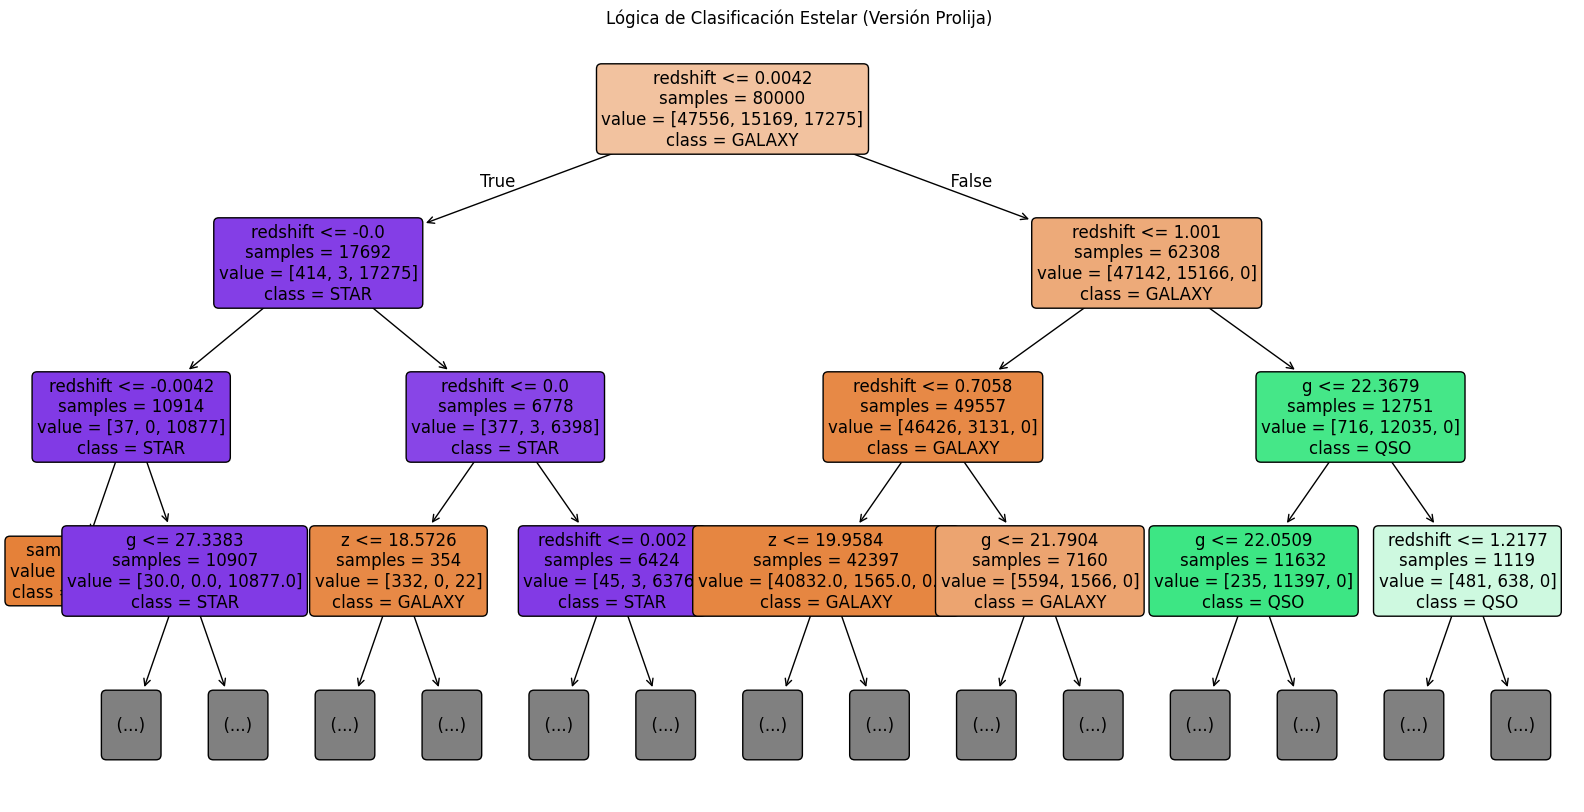

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(tree_base, 
          feature_names=features_fisicas, 
          class_names=tree_base.classes_, 
          filled=True, 
          rounded=True, 
          impurity=False,  
          precision=4,     
          max_depth=3,     # Mostramos solo los niveles de arriba para que se lea
          fontsize=12)

plt.title("Lógica de Clasificación Estelar (Versión Prolija)")
plt.show()

### Paso 2:
#### Ahora empezaremos a agregar las demas variables que tienen que ver con el instrumento que se utilizo en la medición, y analizaremos si tienen relevancia o no en la prediccion.

In [16]:
# 1. Agregamos 'plate' a nuestra lista de variables
features_con_plate = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'plate']

X_p = df[features_con_plate]
y_p = df['class']

# 2. Volvemos a dividir 
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)

# 3. Entrenamos el nuevo árbol
tree_plate = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_plate.fit(X_train_p, y_train_p)

# 4. Vemos si cambió algo
importances_p = pd.Series(tree_plate.feature_importances_, index=features_con_plate).sort_values(ascending=False)
print("--- Nueva Importancia de Variables ---")
print(importances_p)

--- Nueva Importancia de Variables ---
redshift    0.947611
g           0.045154
u           0.003464
z           0.002704
plate       0.001058
i           0.000009
alpha       0.000000
r           0.000000
delta       0.000000
dtype: float64


#### Conclusion: 
##### Incluso agregando variables del instrumento como el plate, el modelo mantiene su criterio físico, lo que demuestra cierta robustez en la prediccion, al menos por ahora. 

In [17]:
# 1. Agregamos 'cam_col' a la lista, sin borrar 'plate'
features_paso_3 = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'plate', 'cam_col']

X_3 = df[features_paso_3]
y_3 = df['class']

# 2. Hacemos el split
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42, stratify=y_3)

# 3. Entrenamos
tree_full = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_full.fit(X_train_3, y_train_3)

# 4. Resultados
importances_3 = pd.Series(tree_full.feature_importances_, index=features_paso_3).sort_values(ascending=False)
print("--- Importancia de Variables ---")
print(importances_3)

--- Importancia de Variables ---
redshift    0.947611
g           0.045121
u           0.003464
z           0.002737
plate       0.001058
i           0.000009
delta       0.000000
alpha       0.000000
r           0.000000
cam_col     0.000000
dtype: float64


##### Vemos que el modelo sigue prefiriendo redshift y la variable cam_col queda completamente descartada ya que no aporta valor predictivo, sigamos agregando las demas variables tecnicas a ver que encontramos

In [18]:
# 1. Agregamos run_ID sin quitar las demas
features_paso_4 = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'plate', 'cam_col', 'run_ID']

X_4 = df[features_paso_4]
y_4 = df['class']

X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4, y_4, test_size=0.2, random_state=42, stratify=y_4)

# Entrenamos
tree_run = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_run.fit(X_train_4, y_train_4)

# Resultados
importances_4 = pd.Series(tree_run.feature_importances_, index=features_paso_4).sort_values(ascending=False)
print("--- Importancia de Variables (Incluyendo run_ID) ---")
print(importances_4)

--- Importancia de Variables (Incluyendo run_ID) ---
redshift    0.947611
g           0.045121
u           0.003464
z           0.002704
plate       0.001058
run_ID      0.000033
i           0.000009
delta       0.000000
alpha       0.000000
r           0.000000
cam_col     0.000000
dtype: float64


##### Aun sin ningun cambio relevante al agregar esta variable tecnica, probamos con la ultima que queda

In [19]:
# Agregamos field_ID a todo lo anterior
features_final_arbol = [
    'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 
    'redshift', 'plate', 'cam_col', 'run_ID', 'field_ID'
]

X_final = df[features_final_arbol]
y_final = df['class']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

# Entrenamos el árbol final
tree_final = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_final.fit(X_train_f, y_train_f)

# Vemos las importancias una última vez
importances_final = pd.Series(tree_final.feature_importances_, index=features_final_arbol).sort_values(ascending=False)
print("--- Importancia de Variables Final (Árbol Único) ---")
print(importances_final)

--- Importancia de Variables Final (Árbol Único) ---
redshift    0.947611
g           0.045121
u           0.003464
z           0.002704
plate       0.001058
alpha       0.000033
i           0.000009
delta       0.000000
r           0.000000
cam_col     0.000000
run_ID      0.000000
field_ID    0.000000
dtype: float64


#### Conclusion: 
##### Finalmente ninguna de las variables tecnicas agregadas posee algun valor predictivo fuerte o relevante para el analisis, el modelo se queda completamente con el redsfhit y a partir de ahi predice. Esto es bueno por un lado ya que nuestro modelo es un poco inmune al ruido que podrian introducir las demas variables. Sin embargo tampoco pudimos mejorar la precision ni un poco al agregar estas variables, por lo que el modelo esta estancado en 0,96 de precision.

#### Paso 3: Random Forest
##### Ahora implementaremos el metodo random forest a ver si podemos mejorar lo obtenido con el arbol de decision clasico

Accuracy Random Forest: 0.9806

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.94      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000

redshift    0.610239
z           0.075715
i           0.063025
u           0.062276
g           0.059112
plate       0.048340
r           0.043261
alpha       0.010440
delta       0.010376
run_ID      0.007569
field_ID    0.006805
cam_col     0.002843
dtype: float64


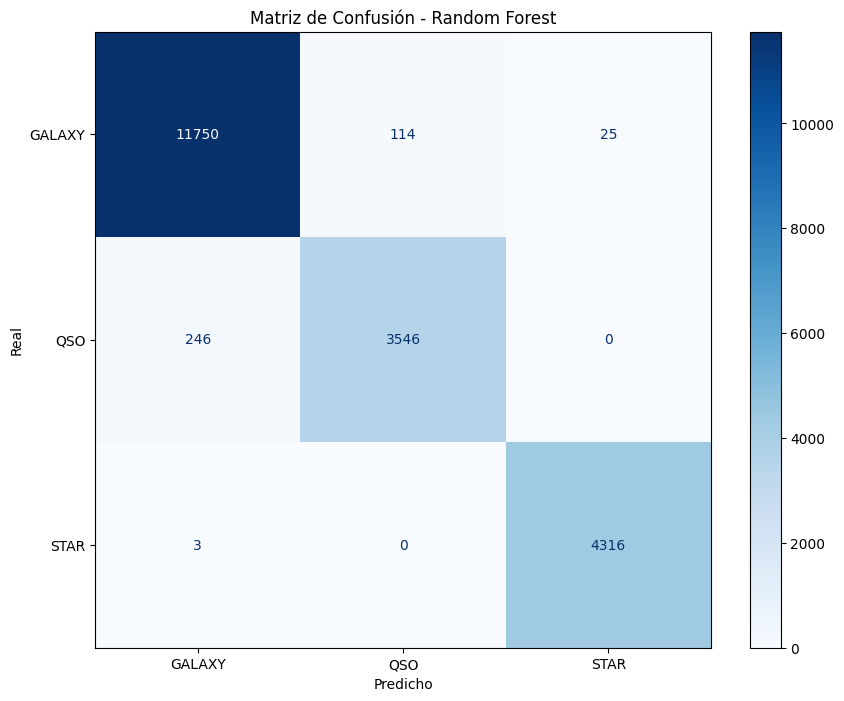

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Usaremos el dataset completo
features_totales = [
    'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 
    'redshift', 'plate', 'cam_col', 'run_ID', 'field_ID'
]

# Creamos el Random Forest
# n_estimators=100 significa que vamos a poner a votar a 100 árboles a la vez
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Entrenamos
rf_final.fit(X_train_f, y_train_f)

# Predicciones
y_pred_rf = rf_final.predict(X_test_f)

print(f"Accuracy Random Forest: {accuracy_score(y_test_f, y_pred_rf):.4f}")
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test_f, y_pred_rf))


# Extraemos las importancias del modelo
importancias = pd.Series(rf_final.feature_importances_, index=features_totales).sort_values(ascending=False)

print(importancias)


# Generamos la matriz de confusion
cm = confusion_matrix(y_test_f, y_pred_rf, labels=rf_final.classes_)

# La graficamos
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_final.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

#### Conclusion final: 
##### A diferencia del arbol simple, el random forest presenta una distribucion de relevancia mucho mas equilibrada entre sus variables. Si bien el redshift sigue siendo la variable principal para predecir, paso de tener un 0,95 de relevancia a tener un 0,61 permitiendo asi que las demas variables tomen mas peso en la toma de decisiones. Esta 'democracia' que fomenta el random forest resulta muy beneficiosa para las metricas del arbol, ya que permite capturar la complejidad de prediccion de los Quasars que teniamos inicialmente con el Arbol simple, aumentando asi su exactitud general, y demas metricas. 

In [ ]:
# 1. Definimos TODAS las variables (Físicas + Técnicas)

X_final = df[features_fisicas]
y_final = df['class']

# 2. DIVIDIR PRIMERO (Clave para que el modelo no haga trampa)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# 3. CREAR Y ENTRENAR (Usamos solo el set de entrenamiento)
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

# 4. PREDICCIONES (Sobre el set de testeo)
y_pred_rf = rf_final.predict(X_test)

# 5. EVALUACIÓN (Comparamos y_test con y_pred_rf)
print(f"Accuracy Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred_rf))

# 6. IMPORTANCIA DE VARIABLES
importances2 = pd.Series(rf_final.feature_importances_, index=features_totales).sort_values(ascending=False)
print("\n--- Importancia de Variables ---")
print(importances2)

# 7. MATRIZ DE CONFUSIÓN
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_rf, labels=rf_final.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_final.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Random Forest (Completo)')
plt.show()

Accuracy Random Forest: 0.9794

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



ValueError: Length of values (8) does not match length of index (12)